# Forward Diffusion on CIFAR-10

This notebook checks the **forward process** from Ho et al., [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) (2020).

The schedule, `extract`, and `q_sample` live in [`02_diffusion.py`](02_diffusion.py). Later notebooks import that file instead of redefining it.

It follows [`01_dataset.ipynb`](01_dataset.ipynb). We do **not** train a U-Net here. The goal is to turn a clean image $x_0$ into a noisy image $x_t$ in one step, for any $t$, and to check that the math looks right.

**Paper vs code indexing.** The paper writes $t = 1, \ldots, T$. PyTorch arrays use $t = 0, \ldots, T-1$. Index `0` is the first, almost-clean step. Index `999` is the last, almost-pure-noise step.


## 1. Setup

In [1]:
import importlib
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torchvision import datasets, transforms

# Numbered .py files are not valid import identifiers.
sys.modules["diffusion"] = importlib.import_module("02_diffusion")
from diffusion import build_schedule, extract, q_sample, to_display


@dataclass(frozen=True)
class Config:
    seed: int = 42
    data_dir: Path = Path("dataset")
    image_size: int = 32
    in_channels: int = 3
    num_steps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 0.02
    batch_size: int = 8


cfg = Config()

# Same seed everywhere so the later random samples/plots stay reproducible.
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)

plt.style.use("seaborn-v0_8-whitegrid")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Dataset directory: {cfg.data_dir.resolve()}")
print(cfg)


PyTorch: 2.13.0
Device: cpu
CUDA available: False
Dataset directory: /Users/branko.grbic/Documents/Faculty/MATF-MU-2026-DDPM-Implementation/dataset
Config(seed=42, data_dir=PosixPath('dataset'), image_size=32, in_channels=3, num_steps=1000, beta_start=0.0001, beta_end=0.02, batch_size=8)


## 2. Load model-ready CIFAR-10

Training later uses a random horizontal flip. This notebook skips the flip so $x_0$ stays fixed while we compare it to $x_t$.

Unconditional DDPM training uses the official 50k training images and ignores labels. The 10k test set is not a classification hold-out; we leave it for later qualitative comparison or optional FID.

Training images: 50000
First image class: frog
x0 shape: (1, 3, 32, 32)
Value range: [-1.000, 1.000]


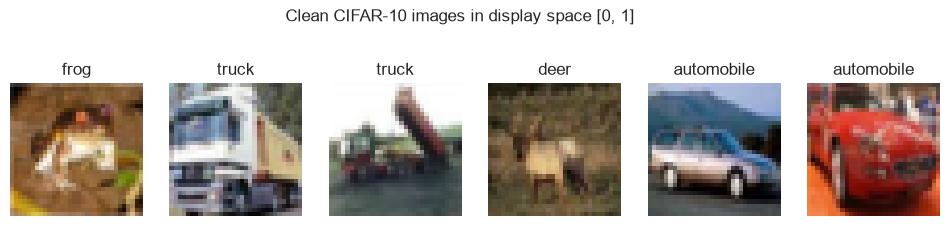

In [2]:
to_minus_one_one = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

download = not (cfg.data_dir / "cifar-10-batches-py" / "test_batch").exists()
train_images = datasets.CIFAR10(
    root=cfg.data_dir, train=True, download=download, transform=to_minus_one_one
)

clean_image, clean_label = train_images[0]
x0 = clean_image.unsqueeze(0).to(device)

print(f"Training images: {len(train_images)}")
print(f"First image class: {train_images.classes[clean_label]}")
print(f"x0 shape: {tuple(x0.shape)}")
print(f"Value range: [{x0.min().item():.3f}, {x0.max().item():.3f}]")

assert x0.shape == (1, cfg.in_channels, cfg.image_size, cfg.image_size)
assert x0.min() >= -1.01 and x0.max() <= 1.01

fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for ax, index in zip(axes, range(6)):
    image, label = train_images[index]
    ax.imshow(to_display(image).permute(1, 2, 0).cpu().numpy())
    ax.set_title(train_images.classes[label])
    ax.axis("off")
fig.suptitle("Clean CIFAR-10 images in display space [0, 1]", y=1.08)
plt.show()


## 3. Forward process

The forward Markov chain adds a little Gaussian noise at each step. Each $\beta_t$ is chosen in advance; $\alpha_t = 1 - \beta_t$ keeps the remaining signal:

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t;\ \sqrt{\alpha_t}\, x_{t-1},\ \beta_t I\big)
$$

Define $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$. Then we do **not** have to simulate all previous steps. One random $t$ is enough:

$$
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)
$$

That closed form is `q_sample` in [`02_diffusion.py`](02_diffusion.py). Later training will sample $t$ uniformly, build $x_t$, and ask a U-Net to predict $\varepsilon$.


## 4. Linear beta schedule

The paper uses a linear schedule from $10^{-4}$ to $0.02$ over $T = 1000$ steps. [`02_diffusion.py`](02_diffusion.py) precomputes every coefficient once. `posterior_variance` is the reverse-process variance $\tilde{\beta}_t$; sampling will need it in `07_sample_eval.ipynb`.


In [3]:
schedule = build_schedule(cfg.num_steps, cfg.beta_start, cfg.beta_end).to(device)

assert schedule.betas.shape == (cfg.num_steps,)
assert torch.all((schedule.betas > 0) & (schedule.betas < 1))
assert torch.all(schedule.alpha_bars[1:] <= schedule.alpha_bars[:-1])
assert torch.isfinite(schedule.alpha_bars).all()
assert torch.isfinite(schedule.posterior_variance).all()
assert schedule.posterior_variance[0].item() == 0.0

preview_steps = [0, 100, 300, 500, 700, 999]
preview = pd.DataFrame(
    {
        "t": preview_steps,
        "beta_t": [schedule.betas[t].item() for t in preview_steps],
        "alpha_t": [schedule.alphas[t].item() for t in preview_steps],
        "alpha_bar_t": [schedule.alpha_bars[t].item() for t in preview_steps],
        "signal_sqrt_alpha_bar": [schedule.sqrt_alpha_bars[t].item() for t in preview_steps],
        "noise_sqrt_one_minus_alpha_bar": [
            schedule.sqrt_one_minus_alpha_bars[t].item() for t in preview_steps
        ],
    }
)
display(preview.round(6))
print(
    f"alpha_bar starts at {schedule.alpha_bars[0].item():.6f} "
    f"and ends at {schedule.alpha_bars[-1].item():.6e}"
)


,t,beta_t,alpha_t,alpha_bar_t,signal_sqrt_alpha_bar,noise_sqrt_one_minus_alpha_bar
0,0,0.000100,0.999900,0.999900,0.999950,0.010001
1,100,0.002092,0.997908,0.895141,0.946119,0.323819
2,300,0.006076,0.993924,0.394011,0.627703,0.778453
3,500,0.010060,0.989940,0.077797,0.278921,0.960314
4,700,0.014044,0.985956,0.006868,0.082875,0.996560
5,999,0.020000,0.980000,0.000040,0.006353,0.999980


alpha_bar starts at 0.999900 and ends at 4.035830e-05


## 5. How the coefficients change with $t$

$\bar{\alpha}_t$ must fall monotonically. Early $t$ still keep most of $x_0$ (`signal`); late $t$ are dominated by $\varepsilon$ (`noise`).

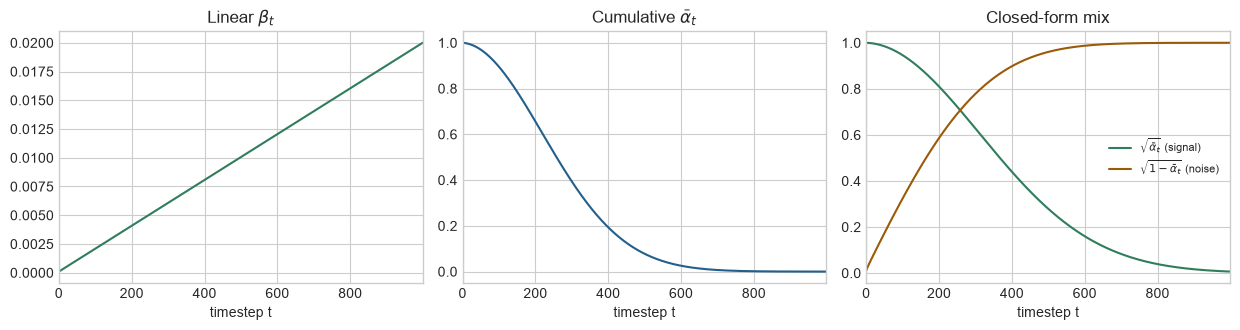

In [4]:
steps = np.arange(cfg.num_steps)
betas = schedule.betas.detach().cpu().numpy()
alpha_bars = schedule.alpha_bars.detach().cpu().numpy()
signal = schedule.sqrt_alpha_bars.detach().cpu().numpy()
noise_scale = schedule.sqrt_one_minus_alpha_bars.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

axes[0].plot(steps, betas, color="#2f7d5b")
axes[0].set_title(r"Linear $\beta_t$")
axes[0].set_xlabel("timestep t")

axes[1].plot(steps, alpha_bars, color="#235f8c")
axes[1].set_title(r"Cumulative $\bar{\alpha}_t$")
axes[1].set_xlabel("timestep t")

axes[2].plot(steps, signal, label=r"$\sqrt{\bar{\alpha}_t}$ (signal)", color="#2f7d5b")
axes[2].plot(steps, noise_scale, label=r"$\sqrt{1-\bar{\alpha}_t}$ (noise)", color="#9b5a08")
axes[2].set_title("Closed-form mix")
axes[2].set_xlabel("timestep t")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlim(0, cfg.num_steps - 1)

plt.tight_layout()
plt.show()

## 6. Coefficient extraction

A training batch uses a **different random $t$ per image**. `extract` in [`02_diffusion.py`](02_diffusion.py) gathers one scalar from a length-$T$ tensor and reshapes it to `[B, 1, 1, 1]` so it broadcasts over channels and pixels.


In [5]:
mixed_timesteps = torch.tensor([0, 100, 500, 999], device=device)
gathered = extract(schedule.alpha_bars, mixed_timesteps, (4, cfg.in_channels, cfg.image_size, cfg.image_size))

print(f"extract output shape: {tuple(gathered.shape)}")
print("gathered alpha_bar:", gathered.view(-1).tolist())

assert gathered.shape == (4, 1, 1, 1)
assert torch.allclose(gathered.view(-1), schedule.alpha_bars[mixed_timesteps])


extract output shape: (4, 1, 1, 1)
gathered alpha_bar: [0.9998999834060669, 0.8951413631439209, 0.07779665291309357, 4.035830352222547e-05]


## 7. Closed-form noising: `q_sample`

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon$$

At $t = 0$ the result should stay close to $x_0$. At $t = T-1$ it should look like the sampled Gaussian noise.


In [6]:
noise = torch.randn_like(x0)
xt_first = q_sample(x0, torch.tensor([0], device=device), schedule, noise)
xt_last = q_sample(x0, torch.tensor([cfg.num_steps - 1], device=device), schedule, noise)

print(f"xt shape: {tuple(xt_first.shape)}")
print(f"Mean |x_0 - x_t| at t=0:   {(xt_first - x0).abs().mean().item():.4f}")
print(f"Mean |ε - x_t| at t=999:   {(xt_last - noise).abs().mean().item():.4f}")
print(f"x_t at t=999 mean/std:     {xt_last.mean().item():.3f} / {xt_last.std().item():.3f}")

assert xt_first.shape == x0.shape == xt_last.shape
assert torch.isfinite(xt_first).all() and torch.isfinite(xt_last).all()
# First step barely moves the image; last step is dominated by the same ε we added.
assert (xt_first - x0).abs().mean() < 0.05
assert (xt_last - noise).abs().mean() < 0.15


xt shape: (1, 3, 32, 32)
Mean |x_0 - x_t| at t=0:   0.0079
Mean |ε - x_t| at t=999:   0.0024
x_t at t=999 mean/std:     0.004 / 0.994


## 8. Forward-noising visualization

Reuse one $\varepsilon$ across timesteps so the same noise pattern fades in as $\sqrt{\bar{\alpha}_t}$ shrinks. That is a correctness check and a figure for the final report.

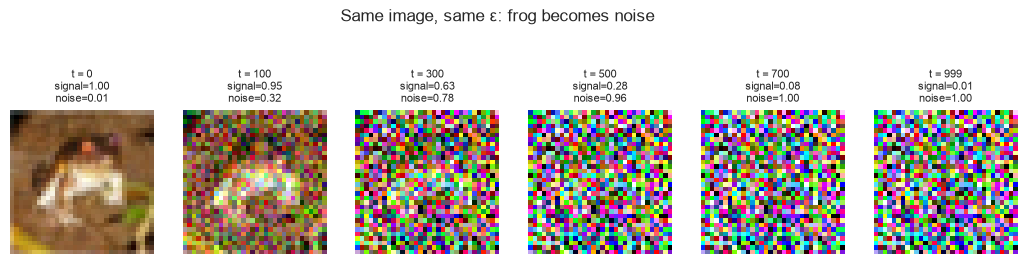

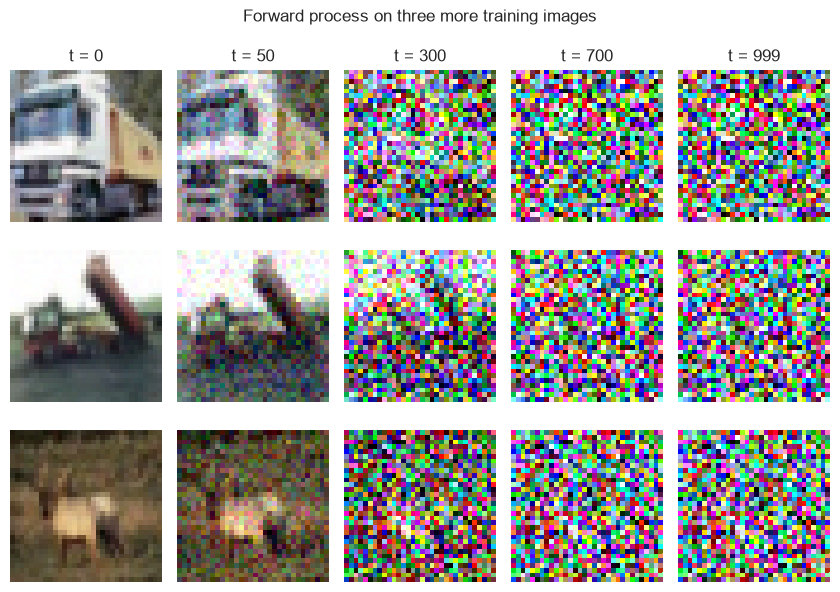

In [7]:
viz_steps = [0, 100, 300, 500, 700, 999]
shared_noise = torch.randn_like(x0)

fig, axes = plt.subplots(1, len(viz_steps), figsize=(13, 2.6))
for ax, timestep in zip(axes, viz_steps):
    xt = q_sample(x0, torch.tensor([timestep], device=device), schedule, shared_noise)
    ax.imshow(to_display(xt[0]).permute(1, 2, 0).cpu().numpy())
    ax.set_title(
        f"t = {timestep}\n"
        f"signal={schedule.sqrt_alpha_bars[timestep].item():.2f}\n"
        f"noise={schedule.sqrt_one_minus_alpha_bars[timestep].item():.2f}",
        fontsize=8,
    )
    ax.axis("off")
fig.suptitle(
    f"Same image, same ε: {train_images.classes[clean_label]} becomes noise",
    y=1.16,
)
plt.show()

# A few more images, fewer timesteps, to show the schedule is not image-specific.
extra_indices = [1, 2, 3]
extra_steps = [0, 50, 300, 700, 999]
fig, axes = plt.subplots(len(extra_indices), len(extra_steps), figsize=(8.5, 6.2))
for row, index in enumerate(extra_indices):
    image, label = train_images[index]
    image = image.unsqueeze(0).to(device)
    image_noise = torch.randn_like(image)
    for col, timestep in enumerate(extra_steps):
        xt = q_sample(image, torch.tensor([timestep], device=device), schedule, image_noise)
        axes[row, col].imshow(to_display(xt[0]).permute(1, 2, 0).cpu().numpy())
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t = {timestep}")
        if col == 0:
            axes[row, col].set_ylabel(train_images.classes[label], rotation=0, labelpad=28, va="center")
fig.suptitle("Forward process on three more training images", y=0.98)
plt.tight_layout()
plt.show()

## 9. What this notebook proved

- CIFAR-10 images used for the math checks live in $[-1, 1]$ and have shape `[B, 3, 32, 32]`.
- [`02_diffusion.py`](02_diffusion.py) is the source of the linear schedule, `extract`, and `q_sample`.
- The linear schedule is finite, $\beta_t \in (0, 1)$, and $\bar{\alpha}_t$ decreases.
- `extract` can attach a different $t$ to each image in a batch.
- `q_sample` implements $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon$.
- Late timesteps look like Gaussian noise; $t = 0$ stays close to the clean image.
